# 🛡️ Class 9.4 — Regularization: Dropout, BatchNorm, L2 & EarlyStopping
### 301 – Machine Learning Techniques

---

**Learning Goals:**
- Build a model that dramatically overfits, then fix it with each regularization technique
- Apply Dropout, BatchNormalization, L2, and EarlyStopping
- Read overfitting signals from training curves and know which fix to apply

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

np.random.seed(42); tf.random.set_seed(42)
plt.rcParams['figure.figsize'] = (12, 5)

bc = load_breast_cancer()
X, y = bc.data, bc.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

def plot_history(histories, labels, title):
    colors = ['#065A82', '#74C365', '#6C3483', '#C0392B', '#E8A838']
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for i, (hist, label) in enumerate(zip(histories, labels)):
        c = colors[i % len(colors)]
        axes[0].plot(hist.history['accuracy'],     color=c, linewidth=2, label=f'{label} train')
        axes[0].plot(hist.history['val_accuracy'], color=c, linewidth=2, linestyle='--', label=f'{label} val')
        axes[1].plot(hist.history['loss'],         color=c, linewidth=2, label=f'{label} train')
        axes[1].plot(hist.history['val_loss'],     color=c, linewidth=2, linestyle='--', label=f'{label} val')
    for ax, ylabel in zip(axes, ['Accuracy', 'Loss']):
        ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
        ax.legend(fontsize=8, ncol=2); ax.grid(True, alpha=0.3)
    axes[0].set_title(title + ' — Accuracy', fontsize=12, fontweight='bold')
    axes[1].set_title(title + ' — Loss',     fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.show()
print('✅ Ready')

✅ Ready


---
## Part 1 — Create an Overfit Model

Build a network that is far too large for this dataset. Observe the clear train/val gap.

Parameters: 205,569


/Users/tetsuya/.pyenv/versions/3.13.7/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test accuracy: 95.6%


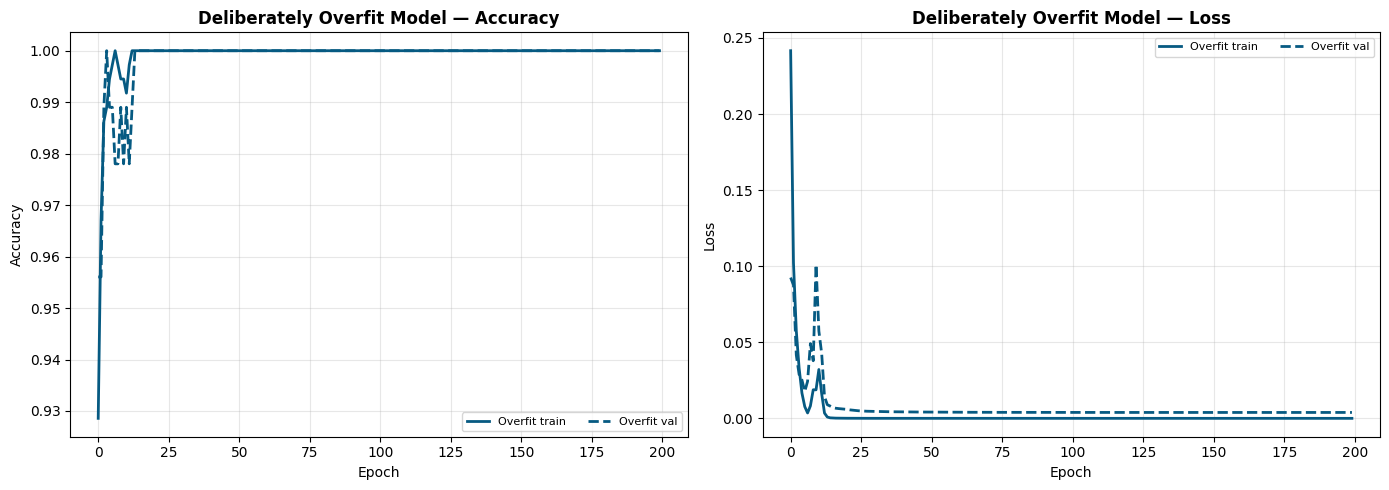

KEY SIGNAL: solid line >> dashed line = OVERFITTING


In [2]:
tf.random.set_seed(42)
overfit_model = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(30,)),
    layers.Dense(256, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(1,   activation='sigmoid')
])
overfit_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print(f'Parameters: {overfit_model.count_params():,}')

hist_overfit = overfit_model.fit(
    X_train_s, y_train, epochs=200, batch_size=16,
    validation_split=0.2, verbose=0
)
_, test_acc_overfit = overfit_model.evaluate(X_test_s, y_test, verbose=0)
print(f'Test accuracy: {test_acc_overfit:.1%}')
plot_history([hist_overfit], ['Overfit'], 'Deliberately Overfit Model')
print('KEY SIGNAL: solid line >> dashed line = OVERFITTING')

---
## Part 2 — Fix It: Dropout

Overfit model:  95.6%
Dropout model:  94.7%


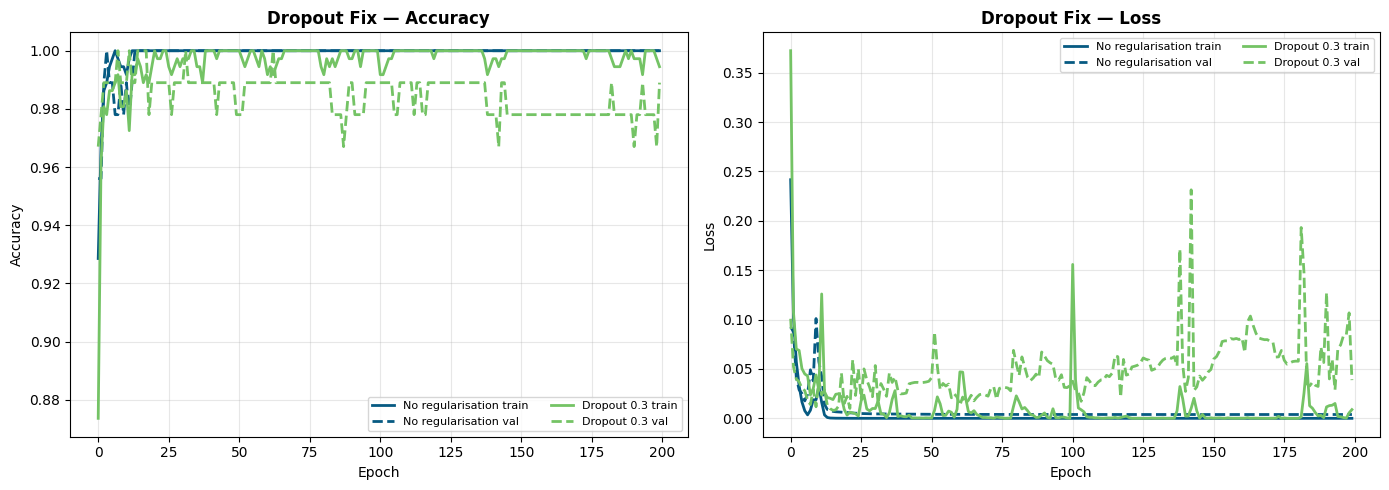

In [3]:
tf.random.set_seed(42)
dropout_model = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(30,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])
dropout_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

hist_dropout = dropout_model.fit(
    X_train_s, y_train, epochs=200, batch_size=16,
    validation_split=0.2, verbose=0
)
_, test_acc_dropout = dropout_model.evaluate(X_test_s, y_test, verbose=0)
print(f'Overfit model:  {test_acc_overfit:.1%}')
print(f'Dropout model:  {test_acc_dropout:.1%}')
plot_history([hist_overfit, hist_dropout], ['No regularisation', 'Dropout 0.3'],
             'Dropout Fix')


---
## Part 3 — Fix It: BatchNormalization

Place BatchNorm AFTER the Dense layer and BEFORE the activation (Dense → BN → Activation).

In [4]:
tf.random.set_seed(42)
batchnorm_model = keras.Sequential([
    layers.Dense(256, input_shape=(30,)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.3),

    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.3),

    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.3),

    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.3),

    layers.Dense(1, activation='sigmoid')
])
batchnorm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

hist_bn = batchnorm_model.fit(
    X_train_s, y_train, epochs=200, batch_size=16,
    validation_split=0.2, verbose=0
)
_, test_acc_bn = batchnorm_model.evaluate(X_test_s, y_test, verbose=0)
print(f'Dropout only:        {test_acc_dropout:.1%}')
print(f'Dropout + BatchNorm: {test_acc_bn:.1%}')


Dropout only:        94.7%
Dropout + BatchNorm: 92.1%


---
## Part 4 — Fix It: EarlyStopping

In [5]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True   # ← CRITICAL: use weights from best epoch, not last
)

tf.random.set_seed(42)
early_model = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(30,)), layers.Dropout(0.3),
    layers.Dense(256, activation='relu'), layers.Dropout(0.3),
    layers.Dense(256, activation='relu'), layers.Dropout(0.3),
    layers.Dense(256, activation='relu'), layers.Dropout(0.3),
    layers.Dense(1,   activation='sigmoid')
])
early_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Set max epochs very high — EarlyStopping will cut it short automatically
hist_early = early_model.fit(
    X_train_s, y_train,
    epochs=500, batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],  # ← add the callback here
    verbose=0
)
_, test_acc_early = early_model.evaluate(X_test_s, y_test, verbose=0)
print(f'Stopped at epoch: {len(hist_early.history["loss"])}  (out of 500 max)')
print(f'EarlyStopping: {test_acc_early:.1%}')

Stopped at epoch: 43  (out of 500 max)
EarlyStopping: 96.5%


---
## Part 5 — Fix It: L2 Regularization

L2 penalises large weights — the same concept as Ridge Regression applied to NN weights.

In [6]:
tf.random.set_seed(42)
l2_model = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(30,),
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(256, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(256, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(256, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(1, activation='sigmoid')
])
l2_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
hist_l2 = l2_model.fit(X_train_s, y_train, epochs=150, batch_size=16,
                        validation_split=0.2, verbose=0)
_, test_acc_l2 = l2_model.evaluate(X_test_s, y_test, verbose=0)

print('=== REGULARISATION COMPARISON ===')
print(f'No regularisation   : {test_acc_overfit:.1%}')
print(f'Dropout (0.3)       : {test_acc_dropout:.1%}')
print(f'Dropout + BatchNorm : {test_acc_bn:.1%}')
print(f'EarlyStopping       : {test_acc_early:.1%}')
print(f'L2 (0.001)          : {test_acc_l2:.1%}')
print()
print('1. Which technique worked best on this dataset?  Answer: Dropout + BatchNorm')
print('2. L2 regularisation connects to which sklearn model you already know?  Answer: Ridge regression')


=== REGULARISATION COMPARISON ===
No regularisation   : 95.6%
Dropout (0.3)       : 94.7%
Dropout + BatchNorm : 92.1%
EarlyStopping       : 96.5%
L2 (0.001)          : 96.5%

1. Which technique worked best on this dataset?  Answer: Dropout + BatchNorm
2. L2 regularisation connects to which sklearn model you already know?  Answer: Ridge regression


---
## ✅ Complete!

**Regularization decision guide:**
- **EarlyStopping**: always — free, safe, prevents wasted epochs
- **Dropout(0.2–0.4)**: when train/val gap > 5%
- **BatchNorm**: for deep (5+ layer) networks or unstable training
- **L2**: additional penalty when Dropout alone is insufficient
